# Fashion Product Image Classification using CNNs
## Dataset: Fashion Product Images (Small) - Kaggle

## Section 1: Imports

In [8]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import cv2
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

In [9]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU Available: True


## Section 2: Configuration

In [10]:

DATA_DIR    = Path('/kaggle/input/datasets/paramaggarwal/fashion-product-images-small')
IMAGES_DIR  = DATA_DIR / 'images'
STYLES_CSV  = DATA_DIR / 'styles.csv'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

IMG_SIZE      = (128, 128)
BATCH_SIZE    = 32
EPOCHS_CNN    = 60
EPOCHS_TL     = 20
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4
MIN_SAMPLES   = 350
TOP_N_CLASSES = 10


## Section 3: Dataset Loading & Exploration

In [11]:
df = pd.read_csv(STYLES_CSV, on_bad_lines='skip')
print(f'Total records in CSV: {len(df)}')
print(df.head())

TARGET_COL = 'subCategory'
print(f'\nTarget column: {repr(TARGET_COL)}')
print(f'Unique classes: {df[TARGET_COL].nunique()}')
print(df[TARGET_COL].value_counts().head(20))

Total records in CSV: 44424
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  

Target column: 'subCategory'
Unique classes: 45
subCategory
Topwear                     15402
Shoes 

In [12]:
df['image_path'] = df['id'].astype(str).apply(
    lambda x: str(IMAGES_DIR / (x + '.jpg'))
)
df['exists'] = df['image_path'].apply(os.path.exists)
df = df[df['exists']].copy()
print(f'Images found on disk: {len(df)}')
df = df.dropna(subset=[TARGET_COL])
print(f'After dropping NaN targets: {len(df)}')

Images found on disk: 44419
After dropping NaN targets: 44419


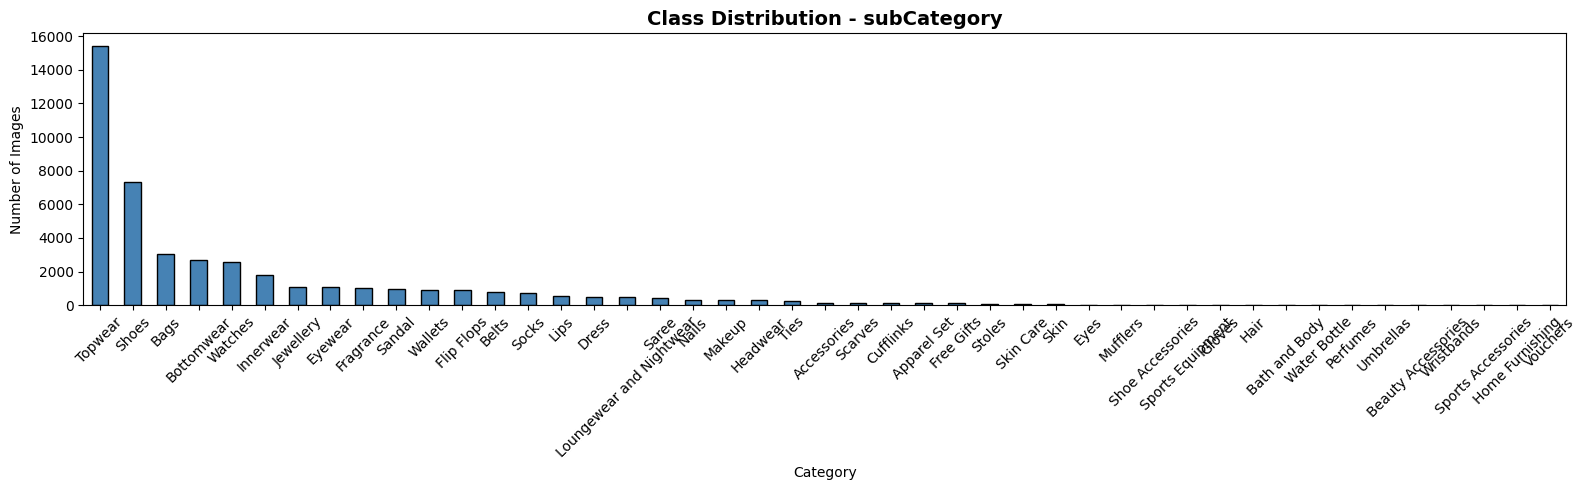

In [13]:
class_counts = df[TARGET_COL].value_counts()
fig, ax = plt.subplots(figsize=(16, 5))
class_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title(f'Class Distribution - {TARGET_COL}', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150)
plt.show()

In [14]:
valid_classes = class_counts[class_counts >= MIN_SAMPLES].index.tolist()
valid_classes = valid_classes[:TOP_N_CLASSES]
df = df[df[TARGET_COL].isin(valid_classes)].copy()
print(f'Selected {len(valid_classes)} classes: {valid_classes}')
print(f'Dataset size after filtering: {len(df)}')

Selected 10 classes: ['Topwear', 'Shoes', 'Bags', 'Bottomwear', 'Watches', 'Innerwear', 'Jewellery', 'Eyewear', 'Fragrance', 'Sandal']
Dataset size after filtering: 36965


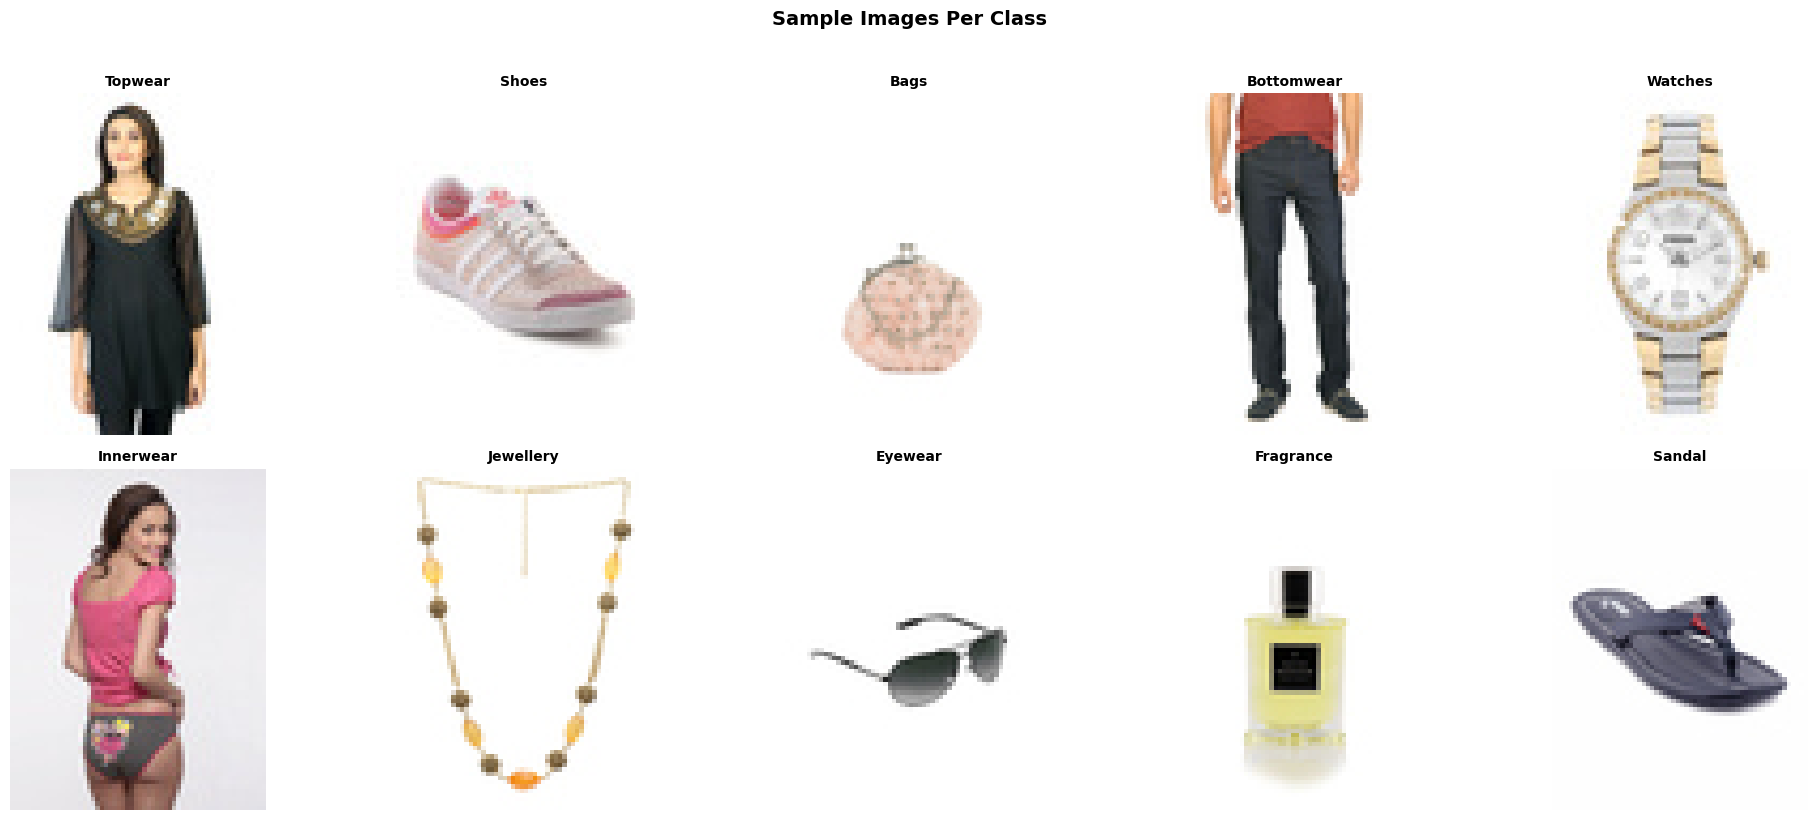

In [15]:

n_display = min(len(valid_classes), 10)
ncols = min(n_display, 5)
nrows = (n_display + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.array(axes).flatten()
for i, cls in enumerate(valid_classes[:n_display]):
    sample = df[df[TARGET_COL] == cls].sample(1, random_state=SEED).iloc[0]
    img = Image.open(sample['image_path']).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10, fontweight='bold')
    axes[i].axis('off')
for j in range(n_display, len(axes)):
    axes[j].axis('off')
plt.suptitle('Sample Images Per Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4: Preprocessing & Train/Val/Test Split

In [16]:

class_to_idx = {cls: i for i, cls in enumerate(sorted(valid_classes))}
idx_to_class = {v: k for k, v in class_to_idx.items()}
df['label'] = df[TARGET_COL].map(class_to_idx)
NUM_CLASSES = len(class_to_idx)
print(f'Number of classes: {NUM_CLASSES}')
print('Label mapping:', class_to_idx)

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label'])
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])
print(f'\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

def load_and_preprocess(image_path, img_size=IMG_SIZE):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(img_size, Image.LANCZOS)
    return np.array(img, dtype=np.float32) / 255.0

def build_arrays(dataframe, img_size=IMG_SIZE):
    X, y = [], []
    for _, row in dataframe.iterrows():
        try:
            X.append(load_and_preprocess(row['image_path'], img_size))
            y.append(row['label'])
        except Exception as exc:
            print(f"Skipped unreadable image: {row['image_path']} ({exc})")
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

print('Loading train set ...')
X_train, y_train = build_arrays(train_df)
print(f'  X_train: {X_train.shape}')

print('Loading val set ...')
X_val, y_val = build_arrays(val_df)
print(f'  X_val:   {X_val.shape}')

print('Loading test set ...')
X_test, y_test = build_arrays(test_df)
print(f'  X_test:  {X_test.shape}')

print(f'Pixel range: [{X_train.min():.3f}, {X_train.max():.3f}]')
print(f'Mean pixel value: {X_train.mean():.3f}')

# Explicit mapping is safer than dict(enumerate(...)) if any label is missing after image loading.
train_classes = np.unique(y_train)
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=train_classes, y=y_train)
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(train_classes, class_weights_arr)}
print(f'\nClass weights:\n{class_weight_dict}')


Number of classes: 10
Label mapping: {'Bags': 0, 'Bottomwear': 1, 'Eyewear': 2, 'Fragrance': 3, 'Innerwear': 4, 'Jewellery': 5, 'Sandal': 6, 'Shoes': 7, 'Topwear': 8, 'Watches': 9}

Train: 25875 | Val: 5545 | Test: 5545
Loading train set ...
  X_train: (25875, 128, 128, 3)
Loading val set ...
  X_val:   (5545, 128, 128, 3)
Loading test set ...
  X_test:  (5545, 128, 128, 3)
Pixel range: [0.000, 1.000]
Mean pixel value: 0.833

Class weights:
{0: 1.2096774193548387, 1: 1.3726790450928381, 2: 3.445406125166445, 3: 3.6546610169491527, 4: 2.043838862559242, 5: 3.4271523178807946, 6: 3.8390207715133533, 7: 0.5034046692607004, 8: 0.24007236964186304, 9: 1.454468802698145}


## Section 5: Data Augmentation

Batches per epoch: train=809, val=174


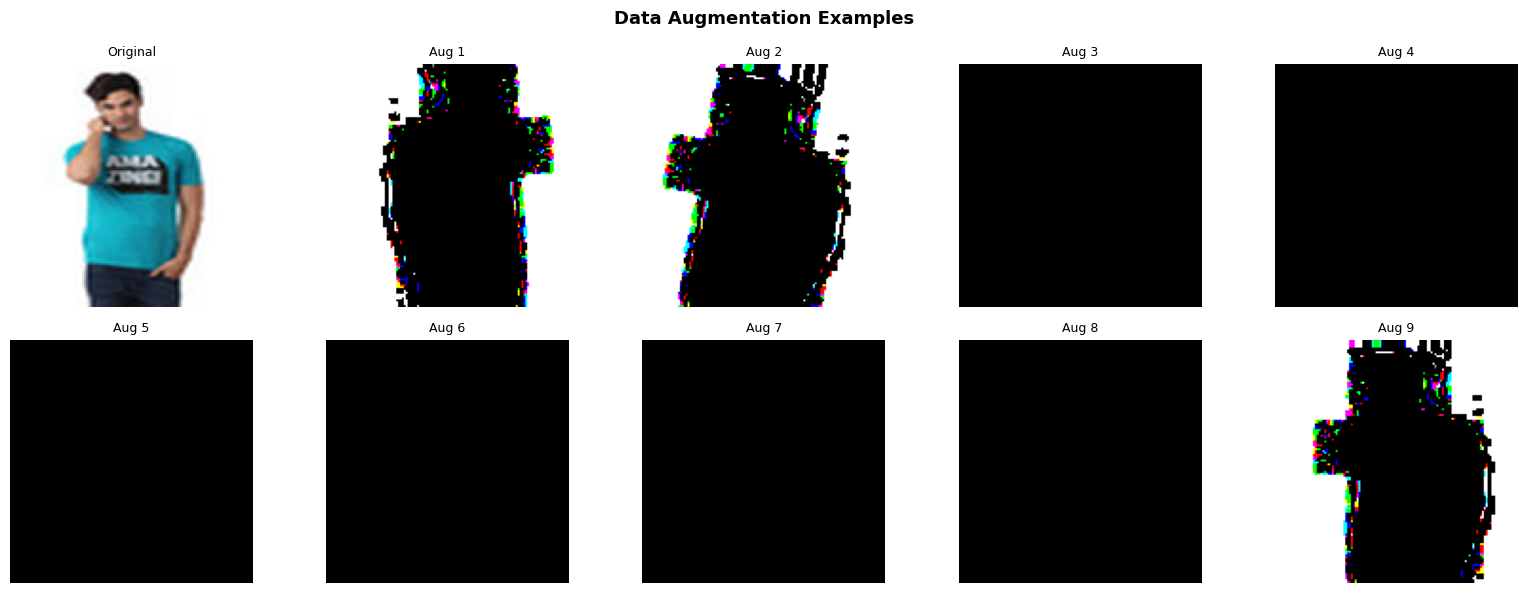

In [17]:

train_datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.12,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)
val_datagen  = ImageDataGenerator()
test_datagen = ImageDataGenerator()

steps_per_epoch = int(np.ceil(len(X_train) / BATCH_SIZE))
val_steps       = int(np.ceil(len(X_val) / BATCH_SIZE))
print(f'Batches per epoch: train={steps_per_epoch}, val={val_steps}')

# Augmentation preview
sample_img = X_train[0:1]
aug_gen    = train_datagen.flow(sample_img, batch_size=1, seed=SEED)
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
axes[0].imshow(sample_img[0])
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')
for i in range(1, 10):
    aug_img = next(aug_gen)[0]
    axes[i].imshow(np.clip(aug_img, 0, 1))
    axes[i].set_title(f'Aug {i}', fontsize=9)
    axes[i].axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'augmentation_examples.png', dpi=150)
plt.show()


## Section 6: Custom CNN Model

In [18]:

def conv_bn_act(x, filters, kernel_size=3, stride=1, name=None):
    x = layers.Conv2D(
        filters, kernel_size, strides=stride, padding='same', use_bias=False,
        kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(WEIGHT_DECAY),
        name=None if name is None else f'{name}_conv')(x)
    x = layers.BatchNormalization(name=None if name is None else f'{name}_bn')(x)
    return layers.Activation('swish', name=None if name is None else f'{name}_swish')(x)

def sep_res_block(x, filters, stride=1, dropout=0.0, name='block'):
    shortcut = x
    if stride != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters, 1, strides=stride, padding='same', use_bias=False,
            kernel_initializer='he_normal',
            kernel_regularizer=keras.regularizers.l2(WEIGHT_DECAY),
            name=f'{name}_shortcut_conv')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_shortcut_bn')(shortcut)

    x = layers.SeparableConv2D(
        filters, 3, strides=stride, padding='same', use_bias=False,
        depthwise_regularizer=keras.regularizers.l2(WEIGHT_DECAY),
        pointwise_regularizer=keras.regularizers.l2(WEIGHT_DECAY),
        name=f'{name}_sepconv1')(x)
    x = layers.BatchNormalization(name=f'{name}_bn1')(x)
    x = layers.Activation('swish', name=f'{name}_swish1')(x)
    x = layers.SeparableConv2D(
        filters, 3, padding='same', use_bias=False,
        depthwise_regularizer=keras.regularizers.l2(WEIGHT_DECAY),
        pointwise_regularizer=keras.regularizers.l2(WEIGHT_DECAY),
        name=f'{name}_sepconv2')(x)
    x = layers.BatchNormalization(name=f'{name}_bn2')(x)
    x = layers.Add(name=f'{name}_add')([x, shortcut])
    x = layers.Activation('swish', name=f'{name}_out')(x)
    if dropout:
        x = layers.SpatialDropout2D(dropout, name=f'{name}_spatial_dropout')(x)
    return x

def build_custom_cnn(input_shape, num_classes):
    inp = keras.Input(shape=input_shape, name='input_image')

    x = conv_bn_act(inp, 32, 3, name='stem1')
    x = conv_bn_act(x, 32, 3, name='stem2')
    x = sep_res_block(x, 64, stride=2, dropout=0.05, name='block1')
    x = sep_res_block(x, 64, stride=1, dropout=0.05, name='block2')
    x = sep_res_block(x, 128, stride=2, dropout=0.10, name='block3')
    x = sep_res_block(x, 128, stride=1, dropout=0.10, name='block4')
    x = sep_res_block(x, 256, stride=2, dropout=0.15, name='block5')
    x = sep_res_block(x, 256, stride=1, dropout=0.15, name='block6')
    x = sep_res_block(x, 384, stride=2, dropout=0.20, name='block7')

    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = layers.Dense(
        256, use_bias=False, kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(WEIGHT_DECAY), name='fc1')(x)
    x = layers.BatchNormalization(name='fc1_bn')(x)
    x = layers.Activation('swish', name='fc1_swish')(x)
    x = layers.Dropout(0.35, name='head_dropout')(x)
    out = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    return keras.Model(inputs=inp, outputs=out, name='CustomCNN_ResidualSeparable')

cnn_model = build_custom_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
cnn_model.summary()


I0000 00:00:1780870926.735492      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "CustomCNN_ResidualSeparable"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_conv (Conv2D) │ (None, 128, 128,  │        864 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_bn            │ (None, 128, 128,  │        128 │ stem1_conv[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_swish         │ (None, 128, 128,  │          0 │ stem1_bn[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_conv (Conv2D) │ (None, 128, 128,  │      9,216 │ stem1_swish[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_bn            │ (None, 128, 128,  │        128 │ stem2_conv[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_swish         │ (None, 128, 128,  │          0 │ stem2_bn[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_sepconv1     │ (None, 64, 64,    │      2,336 │ stem2_swish[0][0] │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn1          │ (None, 64, 64,    │        256 │ block1_sepconv1[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_swish1       │ (None, 64, 64,    │          0 │ block1_bn1[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_sepconv2     │ (None, 64, 64,    │      4,672 │ block1_swish1[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_shortcut_co… │ (None, 64, 64,    │      2,048 │ stem2_swish[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn2          │ (None, 64, 64,    │        256 │ block1_sepconv2[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_shortcut_bn  │ (None, 64, 64,    │        256 │ block1_shortcut_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 64, 64,    │          0 │ block1_bn2[0][0], │
│                     │ 64)               │            │ block1_shortcut_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_out          │ (None, 64, 64,    │          0 │ block1_add[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_spatial_dro… │ (None, 64, 64,    │          0 │ block1_out[0][0]

 Total params: 833,802 (3.18 MB)

 Trainable params: 826,378 (3.15 MB)

 Non-trainable params: 7,424 (29.00 KB)

## Section 7: Training the Custom CNN

In [ ]:

try:
    cnn_optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
except AttributeError:
    cnn_optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

cnn_model.compile(
    optimizer=cnn_optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy')]
)

callbacks_cnn = [
    ModelCheckpoint('best_cnn_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.35, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)
]

# Fresh generators for CNN training. Omitting explicit step counts lets Keras use every sample.
train_gen_cnn = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
val_gen_cnn   = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

history_cnn = cnn_model.fit(
    train_gen_cnn,
    epochs=EPOCHS_CNN,
    validation_data=val_gen_cnn,
    class_weight=class_weight_dict,
    callbacks=callbacks_cnn,
    verbose=1
)

def plot_history(history, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    ax1.set_title(f'{title} - Accuracy', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(history.history['loss'],     label='Train', linewidth=2, color='orange')
    ax2.plot(history.history['val_loss'], label='Val',   linewidth=2, color='red', linestyle='--')
    ax2.set_title(f'{title} - Loss', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Figure saved: {Path(save_path).name}')

plot_history(history_cnn, 'Custom CNN', save_path=FIGURES_DIR / 'cnn_training_curves.png')


Epoch 1/60


I0000 00:00:1780870942.780964     128 service.cc:152] XLA service 0x7b0b20002940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780870942.781045     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780870945.126204     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780870964.492323     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


809/809 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.1570 - loss: 2.7656 - top3_accuracy: 0.4215
Epoch 1: val_accuracy improved from None to 0.01713, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
809/809 ━━━━━━━━━━━━━━━━━━━━ 185s 178ms/step - accuracy: 0.1879 - loss: 2.5962 - top3_accuracy: 0.4780 - val_accuracy: 0.0171 - val_loss: 5.3540 - val_top3_accuracy: 0.0857 - learning_rate: 3.0000e-04
Epoch 2/60
809/809 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.2511 - loss: 2.3578 - top3_accuracy: 0.5479
Epoch 2: val_accuracy improved from 0.01713 to 0.02741, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
809/809 ━━━━━━━━━━━━━━━━━━━━ 107s 132ms/step - accuracy: 0.2727 - loss: 2.2906 - top3_accuracy: 0.5597 - val_accuracy: 0.0274 - val_loss: 4.3519 - val_top3_accuracy: 0.0860 - learning_rate: 3.0000e-04
Epoch 3/60
809/809 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.3214 - loss: 2.1659 - 

## Section 8: Evaluate the Custom CNN

In [ ]:
y_pred_proba_cnn = cnn_model.predict(X_test, verbose=0)
y_pred_cnn       = np.argmax(y_pred_proba_cnn, axis=1)

class_labels = [idx_to_class[i] for i in range(NUM_CLASSES)]
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_labels).plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('Custom CNN - Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_confusion_matrix.png', dpi=150)
plt.show()

report_cnn = classification_report(y_test, y_pred_cnn, target_names=class_labels, digits=4)
print('\nCustom CNN - Classification Report:\n')
print(report_cnn)

test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f'Custom CNN -> Test Loss: {test_loss_cnn:.4f} | Test Accuracy: {test_acc_cnn:.4f}')

## Section 9a : Transfer Learning - MobileNetV2 

In [ ]:
base_mobilenet = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), include_top=False, weights='imagenet')
base_mobilenet.trainable = False

tl_inp = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name='input_tl')
# FIX #5: MobileNetV2 requires [-1, 1] inputs. Original code fed [0,1].
# This mismatch broke the pretrained BatchNorm statistics, capping val_acc at ~38%.
x_rescaled = layers.Rescaling(scale=2.0, offset=-1.0)(tl_inp)
x = base_mobilenet(x_rescaled, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu', name='fc_tl')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.40)(x)
tl_out = layers.Dense(NUM_CLASSES, activation='softmax', name='tl_predictions')(x)
tl_model = keras.Model(inputs=tl_inp, outputs=tl_out, name='MobileNetV2_TL')
tl_model.summary()

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks_tl = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_tl_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

train_gen_p1 = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen_p1   = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

print('\n-- Phase 1: Training classification head (base frozen) --')
history_tl_phase1 = tl_model.fit(
    train_gen_p1, steps_per_epoch=steps_per_epoch, epochs=10,
    validation_data=val_gen_p1, validation_steps=val_steps,
    class_weight=class_weight_dict, callbacks=callbacks_tl, verbose=1)

In [ ]:
# Phase 2: Fine-tune top 40 layers
base_mobilenet.trainable = True
fine_tune_at = len(base_mobilenet.layers) - 40
for layer in base_mobilenet.layers[:fine_tune_at]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

train_gen_p2 = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen_p2   = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

print('\n-- Phase 2: Fine-tuning top 40 layers of MobileNetV2 --')
history_tl_phase2 = tl_model.fit(
    train_gen_p2, steps_per_epoch=steps_per_epoch, epochs=EPOCHS_TL,
    validation_data=val_gen_p2, validation_steps=val_steps,
    class_weight=class_weight_dict, callbacks=callbacks_tl, verbose=1)

def merge_histories(h1, h2):
    merged = {k: h1.history[k] + h2.history[k] for k in h1.history}
    return merged

combined_tl = type('H', (), {'history': merge_histories(history_tl_phase1, history_tl_phase2)})()
plot_history(combined_tl, 'MobileNetV2 (TL)', FIGURES_DIR / 'tl_training_curves.png')

## Section 9b : EfficientNetB0 Transfer Learning
EfficientNetB0 is a stronger backbone than MobileNetV2 for fine-grained

In [ ]:
base_effnet = EfficientNetB0(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), include_top=False, weights='imagenet')
base_effnet.trainable = False

eff_inp = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name='input_eff')
# EfficientNetB0 built-in preprocessing expects [0, 255]
x_eff = layers.Rescaling(scale=255.0)(eff_inp)
x_eff = base_effnet(x_eff, training=False)
x_eff = layers.GlobalAveragePooling2D()(x_eff)
x_eff = layers.Dense(512, activation='relu', name='fc_eff')(x_eff)
x_eff = layers.BatchNormalization()(x_eff)
x_eff = layers.Dropout(0.40)(x_eff)
eff_out = layers.Dense(NUM_CLASSES, activation='softmax', name='eff_predictions')(x_eff)
eff_model = keras.Model(inputs=eff_inp, outputs=eff_out, name='EfficientNetB0_TL')
eff_model.summary()

eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks_eff = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_eff_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

train_gen_e1 = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen_e1   = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

print('\n-- EfficientNetB0 Phase 1: Training head --')
history_eff_p1 = eff_model.fit(
    train_gen_e1, steps_per_epoch=steps_per_epoch, epochs=10,
    validation_data=val_gen_e1, validation_steps=val_steps,
    class_weight=class_weight_dict, callbacks=callbacks_eff, verbose=1)

# Phase 2
base_effnet.trainable = True
for layer in base_effnet.layers[:-50]:
    layer.trainable = False

eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

train_gen_e2 = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen_e2   = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

print('\n-- EfficientNetB0 Phase 2: Fine-tuning top 50 layers --')
history_eff_p2 = eff_model.fit(
    train_gen_e2, steps_per_epoch=steps_per_epoch, epochs=EPOCHS_TL,
    validation_data=val_gen_e2, validation_steps=val_steps,
    class_weight=class_weight_dict, callbacks=callbacks_eff, verbose=1)

combined_eff = type('H', (), {'history': merge_histories(history_eff_p1, history_eff_p2)})()
plot_history(combined_eff, 'EfficientNetB0 (TL)', FIGURES_DIR / 'eff_training_curves.png')

## Section 10: Evaluate All Transfer Learning Models

In [ ]:
# MobileNetV2 evaluation
y_pred_proba_tl = tl_model.predict(X_test, verbose=0)
y_pred_tl       = np.argmax(y_pred_proba_tl, axis=1)
cm_tl = confusion_matrix(y_test, y_pred_tl)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm_tl, display_labels=class_labels).plot(ax=ax, cmap='Greens', xticks_rotation=45)
ax.set_title('MobileNetV2 TL - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tl_confusion_matrix.png', dpi=150)
plt.show()
report_tl = classification_report(y_test, y_pred_tl, target_names=class_labels, digits=4)
print('\nMobileNetV2 TL - Classification Report:\n', report_tl)
test_loss_tl, test_acc_tl = tl_model.evaluate(X_test, y_test, verbose=0)
print(f'MobileNetV2 TL -> Loss: {test_loss_tl:.4f} | Accuracy: {test_acc_tl:.4f}')

# EfficientNetB0 evaluation
y_pred_proba_eff = eff_model.predict(X_test, verbose=0)
y_pred_eff       = np.argmax(y_pred_proba_eff, axis=1)
cm_eff = confusion_matrix(y_test, y_pred_eff)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm_eff, display_labels=class_labels).plot(ax=ax, cmap='Oranges', xticks_rotation=45)
ax.set_title('EfficientNetB0 TL - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eff_confusion_matrix.png', dpi=150)
plt.show()
report_eff = classification_report(y_test, y_pred_eff, target_names=class_labels, digits=4)
print('\nEfficientNetB0 TL - Classification Report:\n', report_eff)
test_loss_eff, test_acc_eff = eff_model.evaluate(X_test, y_test, verbose=0)
print(f'EfficientNetB0 TL -> Loss: {test_loss_eff:.4f} | Accuracy: {test_acc_eff:.4f}')

## Section 11: Model Comparison Table

In [ ]:
def compute_metrics(y_true, y_pred):
    return {
        'Accuracy':          round(accuracy_score(y_true, y_pred), 4),
        'Macro Precision':   round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Macro Recall':      round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Macro F1-Score':    round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Weighted F1-Score': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

metrics_cnn = compute_metrics(y_test, y_pred_cnn)
metrics_tl  = compute_metrics(y_test, y_pred_tl)
metrics_eff = compute_metrics(y_test, y_pred_eff)

comparison_df = pd.DataFrame({
    'Metric':            list(metrics_cnn.keys()),
    'Custom CNN':        list(metrics_cnn.values()),
    'MobileNetV2 TL':    list(metrics_tl.values()),
    'EfficientNetB0 TL': list(metrics_eff.values()),
})
print('\nModel Comparison Table:')
print(comparison_df.to_string(index=False))
comparison_df.to_csv(FIGURES_DIR / 'model_comparison.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
w = 0.25
b1 = ax.bar(x - w,  comparison_df['Custom CNN'],       w, label='Custom CNN',       color='steelblue',  edgecolor='black')
b2 = ax.bar(x,      comparison_df['MobileNetV2 TL'],   w, label='MobileNetV2 TL',   color='darkorange', edgecolor='black')
b3 = ax.bar(x + w,  comparison_df['EfficientNetB0 TL'],w, label='EfficientNetB0 TL',color='seagreen',   edgecolor='black')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(comparison_df['Metric'], rotation=25, ha='right')
ax.set_ylim(0, 1.0); ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in [*b1, *b2, *b3]:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_chart.png', dpi=150)
plt.show()

## Section 12: ROC Curves (One-vs-Rest)

In [ ]:
def plot_roc_multiclass(y_true, y_score, class_labels, title, save_path):
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_labels)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr['micro'], tpr['micro'], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])
    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = plt.cm.get_cmap('tab10', len(class_labels))
    for i in range(len(class_labels)):
        ax.plot(fpr[i], tpr[i], color=cmap(i),
                label=f'{class_labels[i]} (AUC={roc_auc[i]:.3f})', linewidth=1.5)
    ax.plot(fpr['micro'], tpr['micro'], 'k--', linewidth=2.5,
            label=f'Micro-avg (AUC={roc_auc["micro"]:.3f})')
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    return roc_auc

roc_cnn = plot_roc_multiclass(y_test, y_pred_proba_cnn, class_labels,
                               'Custom CNN - ROC (OvR)', FIGURES_DIR / 'cnn_roc_curves.png')
roc_tl  = plot_roc_multiclass(y_test, y_pred_proba_tl,  class_labels,
                               'MobileNetV2 TL - ROC (OvR)', FIGURES_DIR / 'tl_roc_curves.png')
roc_eff = plot_roc_multiclass(y_test, y_pred_proba_eff, class_labels,
                               'EfficientNetB0 TL - ROC (OvR)', FIGURES_DIR / 'eff_roc_curves.png')
print(f'Custom CNN     Micro-AUC: {roc_cnn["micro"]:.4f}')
print(f'MobileNetV2    Micro-AUC: {roc_tl["micro"]:.4f}')
print(f'EfficientNetB0 Micro-AUC: {roc_eff["micro"]:.4f}')

## Section 13: Grad-CAM Visualisation

In [ ]:

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads    = tape.gradient(class_channel, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap  = conv_outputs[0] @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index.numpy())

def overlay_gradcam(original_img, heatmap, alpha=0.4):
    h = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    colored = cv2.applyColorMap(np.uint8(255*h), cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(np.uint8(255*original_img), 1-alpha, colored, alpha, 0)

last_conv_layer = 'block7_sepconv2'
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for row_idx in range(3):
    sample_idx = row_idx * (len(X_test) // 3)
    img = X_test[sample_idx]
    true_cls = idx_to_class[y_test[sample_idx]]
    img_tensor = np.expand_dims(img, axis=0)
    try:
        heatmap, pred_idx = make_gradcam_heatmap(img_tensor, cnn_model, last_conv_layer)
        pred_cls = idx_to_class[pred_idx]
        cam_img  = overlay_gradcam(img, heatmap)
        axes[row_idx][0].imshow(img)
        axes[row_idx][0].set_title(f'Original\nTrue: {true_cls}', fontsize=9)
        axes[row_idx][0].axis('off')
        axes[row_idx][1].imshow(heatmap, cmap='jet')
        axes[row_idx][1].set_title('Grad-CAM Heatmap', fontsize=9)
        axes[row_idx][1].axis('off')
        axes[row_idx][2].imshow(cam_img)
        axes[row_idx][2].set_title(f'Overlay\nPred: {pred_cls}', fontsize=9)
        axes[row_idx][2].axis('off')
        probs = y_pred_proba_cnn[sample_idx]
        top5  = np.argsort(probs)[::-1][:5]
        axes[row_idx][3].barh([idx_to_class[i] for i in top5[::-1]], probs[top5[::-1]], color='steelblue')
        axes[row_idx][3].set_xlim(0, 1)
        axes[row_idx][3].set_title('Top-5 Probabilities', fontsize=9)
    except Exception as e:
        print(f'Grad-CAM failed: {e}')
plt.suptitle('Grad-CAM Visualisations - Custom CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gradcam_visualisations.png', dpi=150)
plt.show()


## Section 14: Error Analysis

In [ ]:
wrong_idx = np.where(y_pred_eff != y_test)[0]
print(f'Misclassified (EfficientNetB0): {len(wrong_idx)}/{len(y_test)} ({100*len(wrong_idx)/len(y_test):.1f}%)')

wrong_true = [idx_to_class[y_test[i]]  for i in wrong_idx]
wrong_pred = [idx_to_class[y_pred_eff[i]] for i in wrong_idx]
print('\nTop-10 confusion pairs (true -> predicted):')
for (t, p), cnt in Counter(zip(wrong_true, wrong_pred)).most_common(10):
    print(f'  {t:25s} -> {p:25s}  ({cnt} errors)')

if len(wrong_idx) >= 8:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        idx = wrong_idx[i]
        ax.imshow(X_test[idx])
        ax.set_title(f'True: {idx_to_class[y_test[idx]]}\nPred: {idx_to_class[y_pred_eff[idx]]}',
                     fontsize=8, color='red')
        ax.axis('off')
    plt.suptitle('Misclassified Samples - EfficientNetB0', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'error_analysis.png', dpi=150)
    plt.show()

## Section 15: Save Models

In [ ]:
cnn_model.save('custom_cnn_final.keras')
tl_model.save('mobilenetv2_tl_final.keras')
eff_model.save('efficientnetb0_tl_final.keras')
print('Models saved.')

## Section 16: Final Summary

In [ ]:

print('=== EXPERIMENT RESULTS SUMMARY (IMPROVED CUSTOM CNN) ===')
print(f'Dataset   : Fashion Product Images (Small)')
print(f'Target    : subCategory')
print(f'Classes   : {NUM_CLASSES}')
print(f'Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}')
print()
print('CUSTOM CNN CHANGES:')
print('  #1 Applied the intended lower LR: LEARNING_RATE = 3e-4, not 13e-4')
print('  #2 Replaced heavy plain ConvNet with residual separable-convolution blocks')
print('  #3 Reduced overly aggressive augmentation/dropout so the model can fit')
print('  #4 Used AdamW/weight decay plus ReduceLROnPlateau for steadier training')
print('  #5 Let Keras consume every batch instead of dropping remainder samples')
print('  #6 Made class-weight mapping explicit and robust after image-loading skips')
print()
print(f'Custom CNN Test Accuracy      : {test_acc_cnn:.4f}')
print(f'MobileNetV2 TL Test Accuracy  : {test_acc_tl:.4f}')
print(f'EfficientNetB0 TL Test Acc    : {test_acc_eff:.4f}')
print(f'CNN Micro-AUC                 : {roc_cnn["micro"]:.4f}')
print(f'MobileNetV2 Micro-AUC         : {roc_tl["micro"]:.4f}')
print(f'EfficientNetB0 Micro-AUC      : {roc_eff["micro"]:.4f}')
print()
print(f'All figures saved to: {FIGURES_DIR.resolve()}')
